In [1]:
import numpy as np
import pandas as pd
import feyn
import seaborn as sns
import matplotlib.pyplot as plt
import sympy
import warnings
import collections
import os

from sklearn.model_selection import train_test_split
from feyn.plots.interactive import interactive_activation_flow
from IPython.display import display
from seaborn import clustermap
from auxiliary import *
from tqdm import tqdm
%matplotlib inline
warnings.filterwarnings('ignore')

This version of feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at `https://abzu.ai/privacy`.


# Data Preparation

## 1) Load the data
The data here consists of 1994 DEGs to be either up-regulated or down-regulated, and 3 omics features, namely copy number viariation, DNA methylation and somatic mutation for the common 677 samples.

In [2]:
data = pd.read_csv('/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/Omics_integration/results/multiomics_all_samples.csv')

# Set row names
data = data.set_index('Gene.Symbol')

In [3]:
data

,Cn_TCGA-3C-AAAU-01,Cn_TCGA-3C-AALI-01,Cn_TCGA-3C-AALJ-01,Cn_TCGA-3C-AALK-01,Cn_TCGA-4H-AAAK-01,Cn_TCGA-5L-AAT0-01,Cn_TCGA-5L-AAT1-01,Cn_TCGA-5T-A9QA-01,Cn_TCGA-A1-A0SE-01,Cn_TCGA-A1-A0SF-01,...,5'UTR_TCGA-Z7-A8R6-01,Nonsense_Mutation_TCGA-Z7-A8R6-01,Splice_Site_TCGA-Z7-A8R6-01,Splice_Region_TCGA-Z7-A8R6-01,Intron_TCGA-Z7-A8R6-01,3'UTR_TCGA-Z7-A8R6-01,3'Flank_TCGA-Z7-A8R6-01,RNA_TCGA-Z7-A8R6-01,logFC,Chromosome
Gene.Symbol,,,,,,,,,,,,,,,,,,,,,
ACAP3,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
AGRN,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3A,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3B,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
ATAD3C,0.008,-1.008,-0.343,-0.019,-0.007,0.023,0.000,-0.651,-0.007,-0.015,...,0,0,0,0,0,0,0,0,Non_sign,chr1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SHANK3,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,-1.73134498491789,chr22
TRABD,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,Non_sign,chr22
TUBGCP6,-0.607,-0.491,-0.704,0.037,-0.016,0.022,0.011,0.919,-0.058,-0.018,...,0,0,0,0,0,0,0,0,Non_sign,chr22


Text(0.5, 1.0, 'Methy Samples')

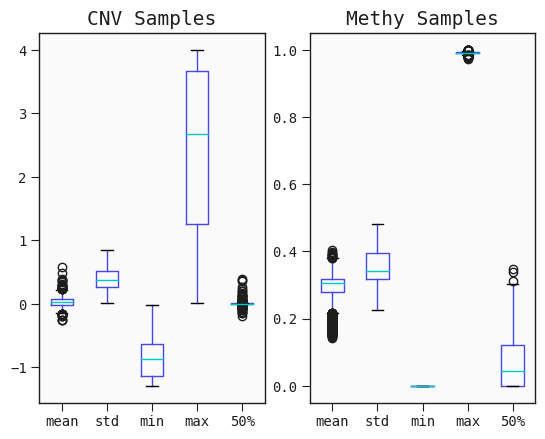

In [4]:
# Compare samples within each omics types
Cn_df = data.filter(like = "Cn").describe().T
Me_df = data.filter(like = "Me").describe().T

fig, axs = plt.subplots(1,2)
Cn_df.boxplot(column = ['mean', 'std', 'min', 'max', '50%'], grid = False, ax = axs[0])
axs[0].set_title('CNV Samples')
Me_df.boxplot(column = ['mean', 'std', 'min', 'max', '50%'], grid = False, ax = axs[1])
axs[1].set_title('Methy Samples')

## 2) Data wrangling
- **Aim:** Aggregate the samples together to reflect an overall situation of each feature type (16 in total).
- **CNV:** We include 2 columns, namely the extreme value and the mean among the samples.
- **Methylation:** 5 columns are included here in terms of the mean beta values within each methylation-related positions.
- **Mutation:** 9 columns here with binary values. We define the value 1 if the gene has this certain type of mutation in at least 1 sample, no matter how many in that sample. Another possible approach to think of is tha if the number of samples having mutation is greater than, for example, 60%, the mutation of this gene is assigned 1, otherwise it is 0.

In [5]:
# Reform the dataset to take the average of cn and me, and the sum of mu types
# Assign the operations 
# extreme_list = ["Cn_", "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']
extreme_list = ["Cn_"]
mean_list = ["Cn", "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf"]
sum_list = ["5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']

# Apply the function for each operation list
agg_sample(data, extreme_list, 'extreme')
agg_sample(data, mean_list, 'mean')
agg_sample(data, sum_list, 'sum')

# Delete data for single samples
data = data[['Cn_', 'Cn', "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf", 
             "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 
             'Intron', "3'UTR", "3'Flank", 'RNA', 'logFC', 'Chromosome']]

# Change column names
data.columns = ['Cn_extreme', 'Cn_mean', "Me_Island", "Me_N_Shore", "Me_S_Shore", "Me_N_Shelf", "Me_S_Shelf", 
             "Mu_5'Flank", "Mu_5'UTR", 'Mu_Nonsense', 'Mu_Splice_Site', 'Mu_Splice_Region', 
             'Mu_Intron', "Mu_3'UTR", "Mu_3'Flank", 'Mu_RNA', 'logFC', 'Chromosome']

In [6]:
data = data.drop(columns = 'Mu_Splice_Site', axis = 1)
data = data.drop(columns = 'Mu_Splice_Region', axis = 1)

In [7]:
# Change mutation columns to binary (if a gene is muated at least in one sample, then we assign 1 to this gene)
data.iloc[:,7:-2] = np.where(data.iloc[:,7:-2] > 0, 1, 0)

In [28]:
# Keep only signle omics type
# Keep CNV
# cnv_data = data.loc[:, data.columns.str.startswith("Cn")]
# target_data = data.iloc[:,-2:]
# data = cnv_data.merge(target_data, on='Gene.Symbol')

# # Keep Methy
# data.loc[:, data.columns.str.endswith("Island")]
# island_data = data.loc[:, data.columns.str.endswith("Island")]
# target_data = data.iloc[:,-2:]
# data = island_data.merge(target_data, on='Gene.Symbol')

# Keep Mutation
mu_data = data.loc[:, data.columns.str.startswith("Mu")]
target_data = data.iloc[:,-2:]
data = mu_data.merge(target_data, on='Gene.Symbol')

data

,Mu_5'Flank,Mu_5'UTR,Mu_Nonsense,Mu_Intron,Mu_3'UTR,Mu_3'Flank,Mu_RNA,Chromosome,gene_type
Gene.Symbol,,,,,,,,,
GABRD,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,chr1,1
ISG15,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,chr1,1
MMEL1,0.0,0.000000,0.0,0.000000,0.671983,0.0,0.000000,chr1,1
PERM1,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,chr1,1
PLCH2,0.0,0.877868,0.0,0.586646,0.000000,0.0,0.000000,chr1,0
...,...,...,...,...,...,...,...,...,...
ADM2,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,chr22,1
IL17REL,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,chr22,1
MAPK8IP2,0.0,0.000000,0.0,0.713449,0.000000,0.0,0.000000,chr22,1


## 3) Change target variable

In [8]:
# Add binary target (0: down-regulated genes / 1: up-regulated genes)
data = data[data['logFC'] != "Non_sign"]
data = data.astype({'logFC': float})
data['gene_type'] = np.where(data['logFC'] < 0, 0, 1)
data = data.drop(columns = 'logFC', axis = 1)

## 4) Data observation

In [8]:
data

,Cn_extreme,Cn_mean,Me_Island,Me_N_Shore,Me_S_Shore,Me_N_Shelf,Me_S_Shelf,Mu_5'Flank,Mu_5'UTR,Mu_Nonsense,Mu_Intron,Mu_3'UTR,Mu_3'Flank,Mu_RNA,Chromosome,gene_type
Gene.Symbol,,,,,,,,,,,,,,,,
GABRD,-1.159,-0.144118,0.690937,0.746071,0.700098,0.000000,0.000000,0,0,0,0,0,0,0,chr1,1
ISG15,-1.159,-0.144118,0.000000,0.000000,0.000000,0.898351,0.568463,0,0,0,0,0,0,0,chr1,1
MMEL1,-1.159,-0.144118,0.638472,0.559872,0.316562,0.640159,0.715801,0,0,0,0,1,0,0,chr1,1
PERM1,-1.159,-0.144118,0.473807,0.484908,0.806221,0.350137,0.495811,0,0,0,0,0,0,0,chr1,1
PLCH2,-1.159,-0.144118,0.576918,0.663391,0.692492,0.640990,0.600646,0,1,0,1,0,0,0,chr1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADM2,1.488,-0.166633,0.190331,0.000000,0.496945,0.000000,0.000000,0,0,0,0,0,0,0,chr22,1
IL17REL,1.488,-0.166633,0.602829,0.683926,0.481898,0.649711,0.000000,0,0,0,0,0,0,0,chr22,1
MAPK8IP2,1.488,-0.166633,0.726042,0.809103,0.897288,0.000000,0.000000,0,0,0,1,0,0,0,chr22,1


In [9]:
data.gene_type.value_counts()

0    1155
1     839
Name: gene_type, dtype: int64

In [9]:
data.Chromosome.unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22'],
      dtype=object)

<AxesSubplot:xlabel='Chromosome'>

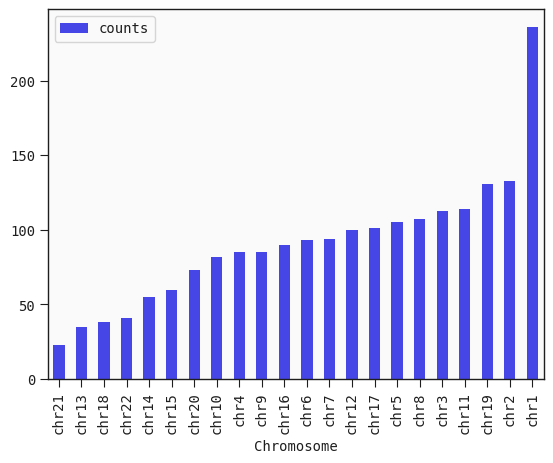

In [10]:
# Check gene number distribution in chromosomes
chrom_df = data.groupby(['Chromosome'])[['gene_type']].count().sort_values(by = ['gene_type']).rename({'gene_type': 'counts'}, axis=1)
chrom_df.plot(kind = "bar")

In [11]:
# Check class ratio of genes in chr1 and chr2
data.loc[(data.Chromosome == "chr1") | (data.Chromosome == "chr2")].gene_type.value_counts()

0    190
1    179
Name: gene_type, dtype: int64

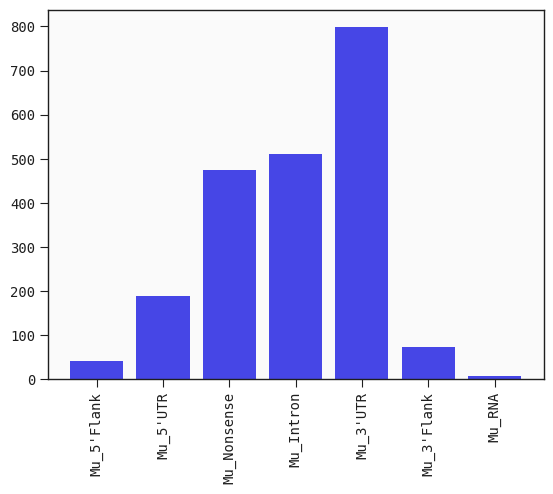

In [46]:
# Count number of muated genes for each type
mutated_genes = dict()
for i in range(7):
    mutated_genes[data.columns[7+i]] = data.iloc[:,7+i].sum()

# Bar plot
names, counts = zip(*mutated_genes.items())
plt.bar(range(len(mutated_genes)), counts, tick_label=names)
plt.xticks(rotation=90)
plt.show()

## 5) Assign categorical features

In [9]:
# Declare categorical if any:
stypes = dict()
for f in data.columns:
    if data[f].dtype =='object':
        stypes[f] = 'c'
        
# stypes = dict(zip(data.columns[2:-1], 9*'c'))
stypes

{'Chromosome': 'c'}

## 6) Validate data

In [10]:
# Define the target variable
# target = "logFC"
# target = "abs_logFC"
target = "gene_type"

try:
    feyn.validate_data(data = data, kind = 'classification', output_name = target, stypes = stypes)
except ValueError as e:
    print(e)

# Train the QLattice

## 1) With simple train/test split 

`ql.update()`: Update QLattice with learnings from a list of models. When updated, the probability density function is updated to encourage those structure, meaning that the QLattice learns to produce models that are similar to what is included in the update. Without updating, the QLattice will keep generating models with a random structure.

In [11]:
# Split data
# train = data.loc[(data.Chromosome != "chr1") & (data.Chromosome != "chr2")]
# test = data.loc[(data.Chromosome == "chr1") | (data.Chromosome == "chr2")]
train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data[target])

# Check for extreme situation
# train = data.iloc[[0, 4], :]
# test = data.drop(data.iloc[[0,4]].index)


# Delete chromosome column
train = train.drop(columns = 'Chromosome', axis = 1)
test = test.drop(columns = 'Chromosome', axis = 1)

In [12]:
train[target].value_counts()

0    924
1    671
Name: gene_type, dtype: int64

### Use `auto_run` function

This occurs in the following steps:

1. Sample models from the QLattice;
2. Fit the models by minimizing [BIC (Bayesian Information Criterion)](https://en.wikipedia.org/wiki/Bayesian_information_criterion);
3. Update the QLattice with the best models' structures;
4. Repeat the process;

In [13]:
# Connecting 
ql = feyn.QLattice(random_seed=42)


# Assign higher weight to class 1
sw = np.where(train[target] == 1, np.sum(train[target] == 0)/sum(train[target]), 1)


# Fit models
models = ql.auto_run(data = train,
                     kind = "classification",
                     output_name = target,
                     stypes = stypes,
                     n_epochs = 100,
                     max_complexity = 10,
                     threads = 4,
                     criterion = "bic",
                     sample_weights = sw)

### Evaluation

In [14]:
mod_df = modsum(models, train, test, 'classification')
mod_df

,Model,AUC Train,AUC Test,BIC,N. Features,Functional form,Loss
0,logreg(Cnmean + tanh(MeIsland)),0.63,0.67,1799.92,2,logreg(Cnmean + tanh(MeIsland)),0.559614
1,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.63,0.68,1801.38,2,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.557761
2,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.63,0.67,1802.44,3,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.558092
3,logreg(Cnmean + tanh(MeIsland**2)),0.63,0.67,1802.82,2,logreg(Cnmean + tanh(MeIsland**2)),0.558212
4,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.63,0.67,1802.98,3,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.558263
5,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.63,0.68,1803.39,2,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.558390
6,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.63,0.68,1804.33,2,logreg(Cnmean + MeIsland + tanh(MeIsland)),0.558684
7,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.63,0.67,1804.37,3,logreg(Cnmean + MeSShore + tanh(MeIsland)),0.558699
8,logreg(Cnmean + MuIntron + tanh(MeIsland)),0.63,0.66,1804.53,3,logreg(Cnmean + MuIntron + tanh(MeIsland)),0.558749
9,logreg(Cnmean + MeSShore + tanh(MeIsland**2)),0.64,0.67,1804.6,3,logreg(Cnmean + MeSShore + tanh(MeIsland**2)),0.556458


In [15]:
pd.to_numeric(mod_df['AUC Train']).mean()

0.631

In [16]:
pd.to_numeric(mod_df['AUC Test']).mean()

0.672

In [18]:
# Save the models
for i in range(10):
    models[i].save('../models/onlyDEG/mc10_top10_models_cscape_binary/top'+str(i)+'.json')

## 2) With cross validation framework
### Training

In [57]:
# Split data
train_val = data.loc[(data.Chromosome != "chr1") & (data.Chromosome != "chr2")]
test = data.loc[(data.Chromosome == "chr1") | (data.Chromosome == "chr2")]

# Delete chromosome column
train_val = train_val.drop(columns = 'Chromosome', axis = 1)
test = test.drop(columns = 'Chromosome', axis = 1)

In [58]:
test[target].value_counts()

0    190
1    179
Name: gene_type, dtype: int64

In [59]:
# Fit models with 5-fold CV
results = crossvalidation_as_framework(train_val,
                                       target,
                                       kind = "classification",
                                       stypes = stypes,
                                       n_epochs = 100,
                                       max_complexity = 10,
                                       criterion = 'bic',
                                       threads = 4)

In [60]:
results

,model_structure,fold,aic,bic,roc_auc_train,accuracy_train,roc_auc_val,accuracy_val,pr_auc,f1,query_string
0,logreg(Cnmean + MeIsland + tanh(MeIsland)),0,1398.464190,1413.974549,0.644325,0.618462,0.653870,0.627692,0.557037,0.451923,"add(tanh(""Me_Island""), add(""Cn_mean"", ""Me_Isla..."
0,logreg(Cnmean + MeIsland + tanh(MeIsland)),0,1399.376463,1414.886822,0.642857,0.619231,0.653085,0.621538,0.556120,0.560311,"add(""Me_Island"", add(tanh(""Me_Island""), ""Cn_me..."
0,logreg(Cnmean + MeIsland + tanh(MeIsland)),0,1399.686968,1415.197326,0.642877,0.623846,0.659837,0.624615,0.565873,0.460829,"add(add(tanh(""Me_Island""), ""Me_Island""), ""Cn_m..."
0,logreg(Cnmean + MeIsland + tanh(MeIsland**2)),0,1396.130235,1416.810714,0.648713,0.617692,0.660975,0.624615,0.559798,0.493274,"add(add(""Cn_mean"", tanh(squared(""Me_Island"")))..."
0,logreg(Cnmean + tanh(MeIsland)),0,1406.761827,1417.102066,0.632885,0.621538,0.663055,0.633846,0.573614,0.547619,"add(""Cn_mean"", tanh(""Me_Island""))"
0,logreg(Cnmean + MeIsland + tanh(MeIsland)**2),0,1396.660253,1417.340731,0.647195,0.620769,0.659523,0.630769,0.559811,0.556863,"add(""Me_Island"", add(squared(tanh(""Me_Island"")..."
0,logreg(Cnmean + MeIsland + Mu3'UTR + tanh(MeIs...,0,1397.750627,1418.431105,0.649521,0.614615,0.663801,0.615385,0.567025,0.508621,"add(add(add(""Me_Island"", ""Cn_mean""), tanh(""Me_..."
0,logreg(Cnmean*MeIsland + tanh(MeIsland)),0,1398.345980,1419.026458,0.643310,0.624615,0.645667,0.630769,0.526925,0.553846,"add(tanh(""Me_Island""), multiply(""Cn_mean"", ""Me..."
0,logreg(Cnmean + tanh(MeIsland**2)),0,1403.701957,1419.212316,0.638188,0.619231,0.668158,0.633846,0.576273,0.522449,"add(""Cn_mean"", tanh(squared(""Me_Island"")))"
0,logreg(Cnmean + MeIsland + Mu3'UTR + tanh(MeIs...,0,1398.556734,1419.237212,0.648834,0.617692,0.662074,0.618462,0.564299,0.548387,"add(""Mu_3'UTR"", add(add(""Cn_mean"", tanh(""Me_Is..."


### Check results

In [61]:
# mean and std of Validation AUC of the top1 models of each fold
results.groupby("fold").first().roc_auc_val.mean(), results.groupby("fold").first().roc_auc_val.std()

(0.6355040037682524, 0.022972810837455067)

In [62]:
# mean and std of Training AUC of the top1 models of each fold
results.groupby("fold").first().roc_auc_train.mean(), results.groupby("fold").first().roc_auc_train.std()

(0.6460683584550165, 0.004881197955469847)

In [63]:
# Top1 model from each fold
results.groupby("fold").first()

,model_structure,aic,bic,roc_auc_train,accuracy_train,roc_auc_val,accuracy_val,pr_auc,f1,query_string
fold,,,,,,,,,,
0,logreg(Cnmean + MeIsland + tanh(MeIsland)),1398.464190,1413.974549,0.644325,0.618462,0.653870,0.627692,0.557037,0.451923,"add(tanh(""Me_Island""), add(""Cn_mean"", ""Me_Isla..."
1,logreg(Cnmean + MeIsland + tanh(MeIsland**2)),1391.971267,1412.651745,0.653185,0.625385,0.649788,0.603077,0.585023,0.477477,"add(add(tanh(squared(""Me_Island"")), ""Cn_mean"")..."
2,logreg(Cnmean + tanh(MeIsland)),1399.698482,1410.038721,0.640318,0.623846,0.638680,0.615385,0.537133,0.433962,"add(tanh(""Me_Island""), ""Cn_mean"")"
3,logreg(Cnmean + tanh(MeIsland)),1391.316831,1401.657070,0.648317,0.627692,0.596169,0.593846,0.499839,0.454936,"add(tanh(""Me_Island""), ""Cn_mean"")"
4,logreg(Cnmean + Mu3'UTR + tanh(MeIsland)),1400.967962,1416.478321,0.644197,0.615385,0.639013,0.621538,0.577964,0.478632,"add(add(tanh(""Me_Island""), ""Mu_3'UTR""), ""Cn_me..."


In [64]:
# Average performance of each fold
results.groupby("fold").mean()

,aic,bic,roc_auc_train,accuracy_train,roc_auc_val,accuracy_val,pr_auc,f1
fold,,,,,,,,
0,1399.543523,1417.121930,0.643870,0.619769,0.659005,0.626154,0.560678,0.520412
1,1396.959516,1414.020910,0.648241,0.624077,0.645427,0.617846,0.568470,0.449754
2,1397.506660,1413.017018,0.644461,0.619615,0.643366,0.621846,0.544891,0.440793
3,1387.097288,1403.641670,0.656484,0.628692,0.596039,0.600000,0.498421,0.425591
4,1399.829365,1417.407771,0.645591,0.619077,0.644202,0.620923,0.582713,0.472397


In [65]:
for model in results.groupby("fold").first()['model_structure']:
    print(model)

logreg(Cnmean + MeIsland + tanh(MeIsland))
logreg(Cnmean + MeIsland + tanh(MeIsland**2))
logreg(Cnmean + tanh(MeIsland))
logreg(Cnmean + tanh(MeIsland))
logreg(Cnmean + Mu3'UTR + tanh(MeIsland))


### Train with top model structures
- Here we assign the corresponding model structure of the top1 model from each fold to train it again using 5 folds. This makes the training more specific so that only the parameters are optimized this time rather than the model structure.
- We keep only the top1 model returned by the QLattice for each fold.

In [66]:
results.groupby("fold").first()['query_string'].values

array(['add(tanh("Me_Island"), add("Cn_mean", "Me_Island"))',
       'add(add(tanh(squared("Me_Island")), "Cn_mean"), "Me_Island")',
       'add(tanh("Me_Island"), "Cn_mean")',
       'add(tanh("Me_Island"), "Cn_mean")',
       'add(add(tanh("Me_Island"), "Mu_3\'UTR"), "Cn_mean")'],
      dtype=object)

In [67]:
best_models_qstrings = results.groupby("fold").first()['query_string'].values

n_folds = 5
random_state = 42
models_trained = []
train_list = []
val_list = []

kfold_test = StratifiedKFold(n_folds, shuffle=True, random_state=random_state)
for i, (train, val) in enumerate(kfold_test.split(train_val, train_val[target])):
        train, val = train_val.iloc[train], train_val.iloc[val]
        train_list.append(train)
        val_list.append(val)
        
        sample_weights = np.where(train[target] == 1,
                                      np.sum(train[target] == 0) / sum(train[target]), 1)
        
        ql = feyn.QLattice(random_state)
        model = ql.auto_run(train, output_name=target, n_epochs=20, kind = "classification",
                             query_string=best_models_qstrings[i], sample_weights=sample_weights, stypes=stypes)[0]
        models_trained.append(model)


In [68]:
# Save the models
for i in range(5):
    models_trained[i].save('../models/onlyDEG/CV_models/model_k'+str(i)+'.json')

### Train the whole train_val data set with the best query string

In [69]:
# Compare the validation AUC score of each fold
for i in range(5):
    print(models_trained[i].roc_auc_score(val_list[i]))

0.6516329094049302
0.6495917726487674
0.6372271942220128
0.5933427539645155
0.6382281362851311


In [72]:
# Fit train_val with the best expression
ql = feyn.QLattice(random_seed=42)
model = ql.auto_run(train_val, output_name=target, n_epochs=100, kind = "classification",
                    query_string=models_trained[0].to_query_string(), stypes=stypes)[0]

In [73]:
model.save('../results/onlyDEG/CV_models/best_model.json')

# Visualization
## 1) Models loading

In [16]:
# Load simple train/test split models
models_list = [x for x in os.listdir('../models/onlyDEG/mc10_top10_models_cscape_binary/') if not x.startswith('.')]
models = []
for i in range(len(models_list)):
    models.append(Model.load('../models/onlyDEG/mc10_top10_models_cscape_binary/'+'top'+str(i)+'.json'))

In [ ]:
# Load cross validation models
path = '../models/onlyDEG/CV_models/'
CV_models = [Model.load(path+'model_k0.json'), Model.load(path+'model_k1.json'),
            Model.load(path+'model_k2.json'), Model.load(path+'model_k3.json'),
            Model.load(path+'model_k4.json')]

In [ ]:
CV_best_model = Model.load('../models/onlyDEG/CV_models/best_model.json')

## 2) Models display

In [17]:
# Display all models
for model in models[0:]:
    feyn.show_model(
        model = model,
        update_display = False
    )

## 3) Single model visualization

### Basic metrics

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="232.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 861 232.0" width="861" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="155.0" width="591" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="481" y="50.0"><title>gene_type
logistic:
w=-0.4880
bias=0.5180</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="71.5">gene_type</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="59.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="483" y="59.0">out</text><line stroke="#1E1E1E" x1="451" x2="481" y1="67.5" y2="67.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="50.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="71.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="59.0">1</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="58.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="76.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="20.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">2</text><line stroke="#1E1E1E" x1="211" x2="241" y1="37.5" y2="28.5" /><line stroke="#1E1E1E" x1="211" x2="241" y1="97.5" y2="46.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="121" y="20.0"><title>Cn_mean
linear:
scale=2.072016
scale offset=0.047089
w=-1.491725
bias=-1.4057</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="166.0" y="41.5">Cn_mean</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="209" y="29.0">3</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="123" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="121" y="80.0"><title>tanh</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="166.0" y="101.5">tanh</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="209" y="89.0">4</text><line stroke="#1E1E1E" x1="91" x2="121" y1="67.5" y2="97.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="1" y="50.0"><title>Me_Island
linear:
scale=2.095481
scale offset=0.245296
w=9.665308
bias=3.6643</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="46.0" y="71.5">Me_Island</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="89" y="59.0">5</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="3" y="59.0">num</text><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="80.0"><title>Mu_Intron
linear:
scale=2.000000
scale offset=0.078370
w=0.359025
bias=2.1263</title></rect><text fill="#1E1E1E" font-family="monospace" fo
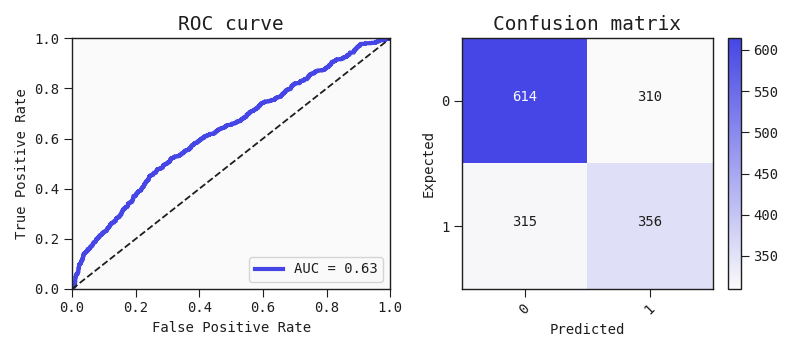
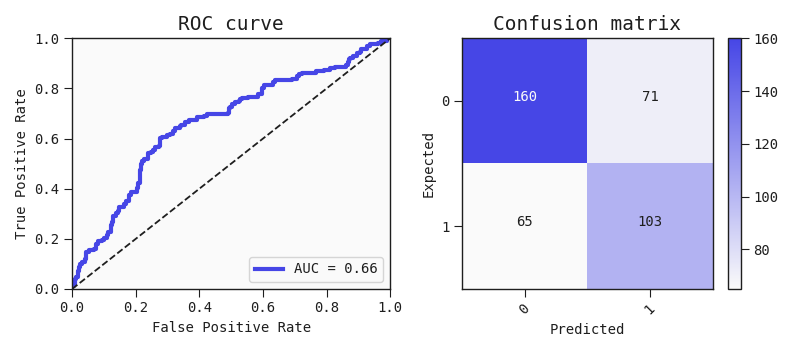

In [33]:
# Basic metrics
models[8].plot(data = train, compare_data = test)

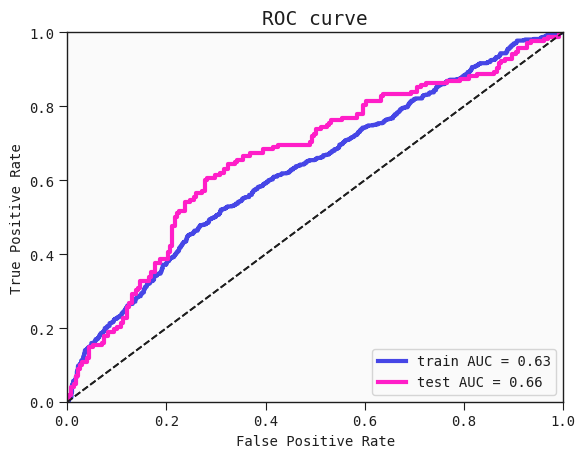

In [34]:
models[8].plot_roc_curve(train, label='train')
models[8].plot_roc_curve(test, label='test', ax=plt.gca())

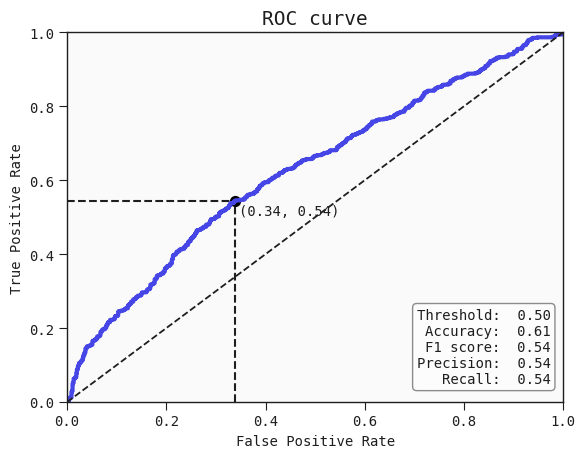

In [23]:
# ROC cureve with threshold (the probability for a DEG to be up-regulated)
models[0].plot_roc_curve(train, threshold=0.5)

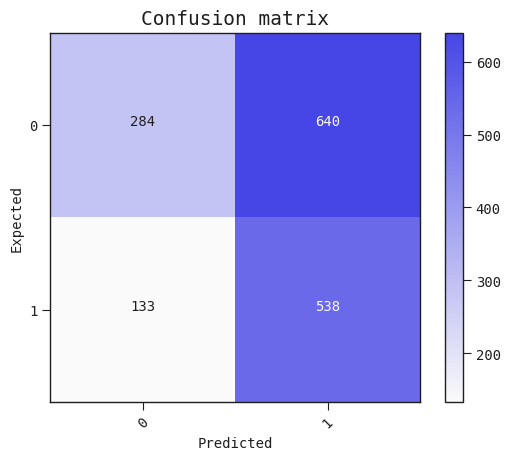

In [24]:
# Confusion matrix
models[0].plot_confusion_matrix(train, threshold=0.4)

### Probability plot

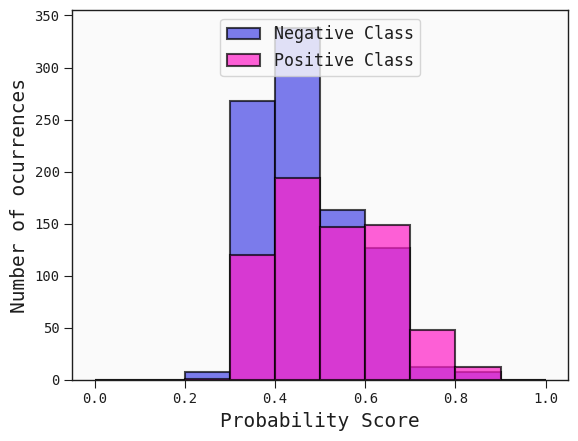

In [35]:
# Probability scores
models[8].plot_probability_scores(train)

### Signal plot

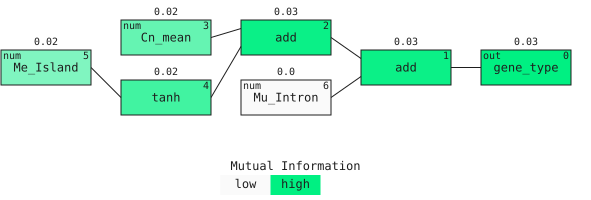

In [39]:
models[8].plot_signal(train, corr_func = "mutual_information")

In [23]:
interactive_activation_flow(models[0], train)

interactive(children=(FloatSlider(value=0.47721749798536, description='Me_Island', max=0.95443499597072), Floa…

<function feyn.plots.interactive._graph_flow.interactive_activation_flow.<locals>.flow(**kwargs)>

### Response plot

In [40]:
# 1D-response plot
models[8].interactive_response_1d(data = train)

interactive(children=(Dropdown(description='by', options=('Mu_Intron', 'Cn_mean', 'Me_Island'), value='Mu_Intr…

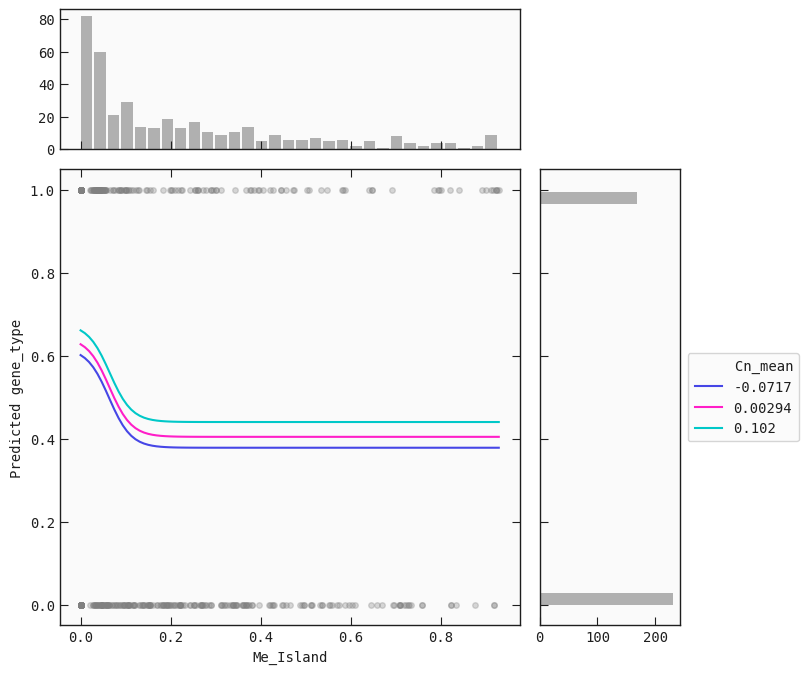

In [26]:
# Combined 1D-response plot
show_quantiles = 'Cn_mean'
fixed = {}
fixed[show_quantiles] = [
    train[show_quantiles].quantile(q=0.25),
    train[show_quantiles].quantile(q=0.5),
    train[show_quantiles].quantile(q=0.75)
]

models[0].plot_response_1d(test, by = "Me_Island", input_constraints = fixed)
#                             filename=pathname+projectname+'bestmodel_response1d_age'+'.pdf')

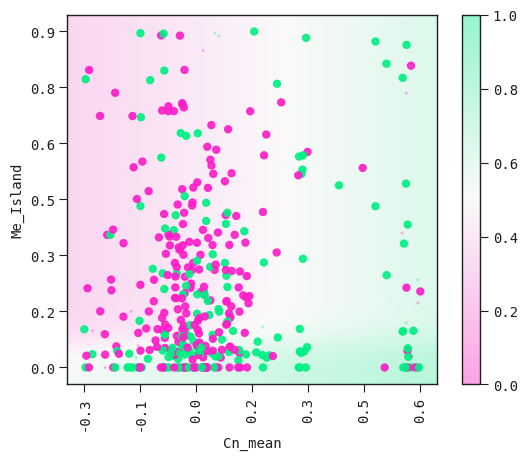

In [42]:
# 2D-response plot
models[8].plot_response_2d(data = test, fixed = {"Mu_Intron": 0})

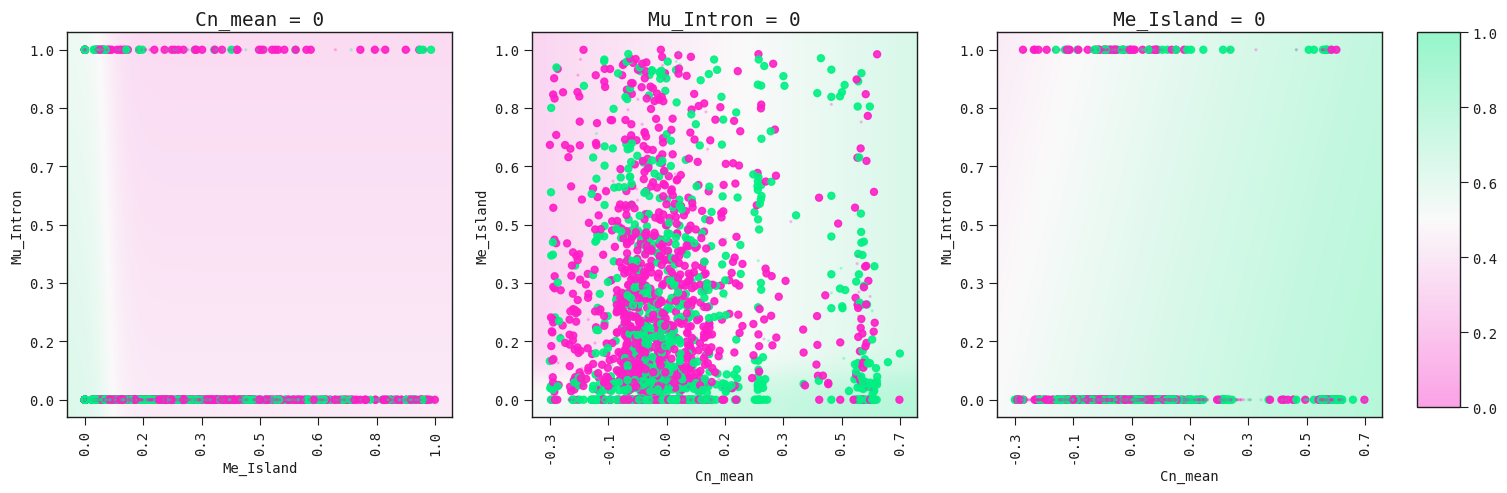

In [74]:
titles = [('Cn_mean = 0'), 
          ('Mu_Intron = 0'),
          ('Me_Island = 0')]

fig, axs = plt.subplots(1, 3, figsize=(17, 5))

for i,f in enumerate(['Cn_mean', 'Mu_Intron', 'Me_Island']):
    models[8].plot_response_2d(data, fixed={f: 0}, ax=axs[i])
    axs[i].set_title(titles[i])
    
img = axs[i].get_images()[0]
cax = fig.add_axes([0.92, 0.13, 0.025, 0.75])
fig.colorbar(img, cax=cax)
plt.show()

### Features from the top 10 models

In [18]:
# Count selected features
# models = models_trained

# Extract all features
feat_list = list()
for i in range(len(models)):
    for fea in models[i].features:
        feat_list.append(fea)

# Count
count_features = collections.Counter(feat_list)
count_features_df = pd.DataFrame(count_features.items(),columns=['Features', 'Count']).sort_values('Count', ascending=False)

count_features_df

,Features,Count
0,Cn_mean,10
1,Me_Island,10
2,Me_S_Shore,4
3,Mu_Intron,1


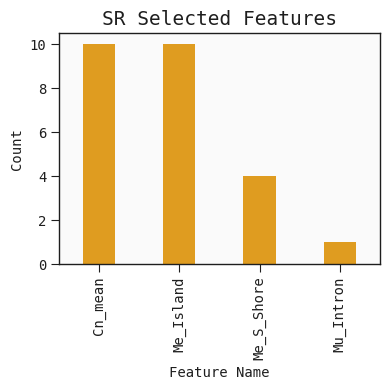

In [19]:
# Bar plot
fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=count_features_df.Features, y=count_features_df.Count, ax=ax, color='orange', width=0.4)
plt.xticks(range(len(count_features_df.Features)), count_features_df.Features, rotation=90)
plt.title("SR Selected Features")
plt.xlabel("Feature Name")
plt.ylabel("Count")
plt.tight_layout()

In [ ]:
# Feature pair plot
features_data = train[['Cn_TCGA-B6-A0RM-01', 'Cn_TCGA-BH-A1FJ-01','Cn_TCGA-AC-A8OR-01']]
sns.pairplot(features_data, hue = target)

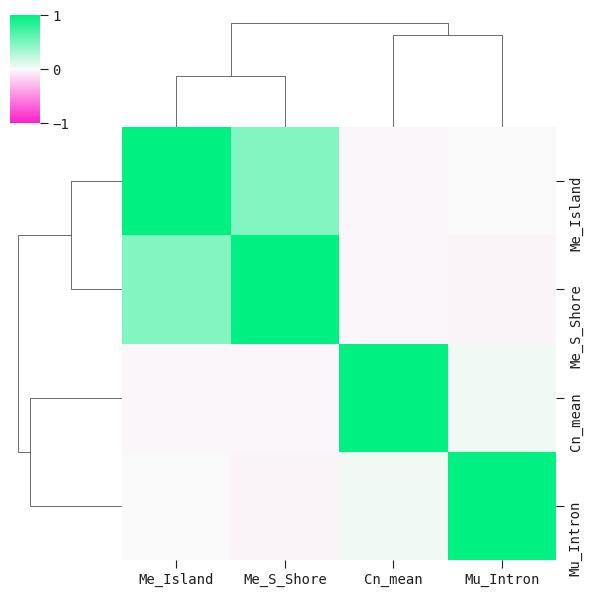

In [31]:
# Correlation map of the inputs
inputs_list = []
for m in models:
    for i in m.inputs:
        if i not in inputs_list:
            inputs_list.append(i)
            
corr_inputs = data[inputs_list].corr()
cluster_map_args = {'cmap': 'feyn-diverging', 'vmin': -1, 'vmax': 1}

clustermap(corr_inputs, **cluster_map_args, figsize=(6, 6))
# plt.savefig('../figures/classfication_clustermap.pdf', dpi=300, bbox_inches='tight')

### Feature distribution plot

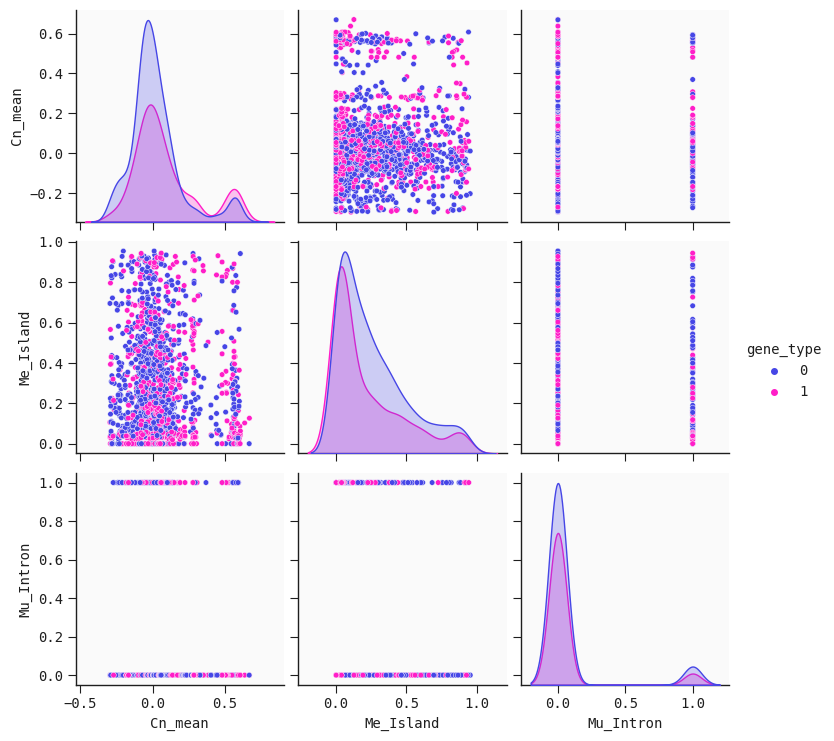

In [75]:
features_data = data[["Cn_mean", "Me_Island", "Mu_Intron", "gene_type"]]
sns.pairplot(features_data, hue = 'gene_type')

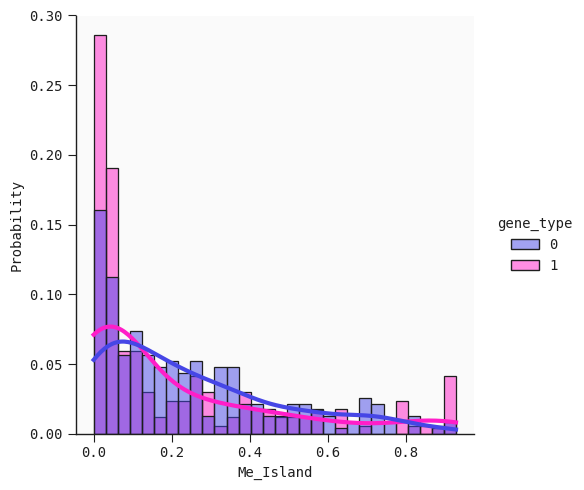

In [51]:
sns.displot(test[["Me_Island", "gene_type"]], x="Me_Island", hue="gene_type", kde=True, bins=30, stat="probability", common_norm=False)

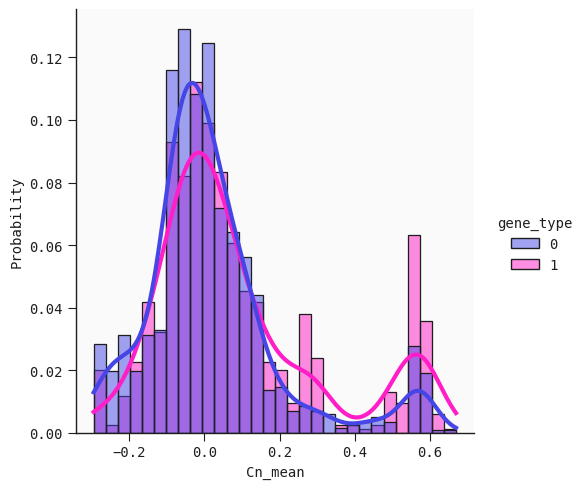

In [52]:
sns.displot(data[["Cn_mean", "gene_type"]], x="Cn_mean", hue="gene_type", kde=True, bins=30, stat="probability", common_norm=False)

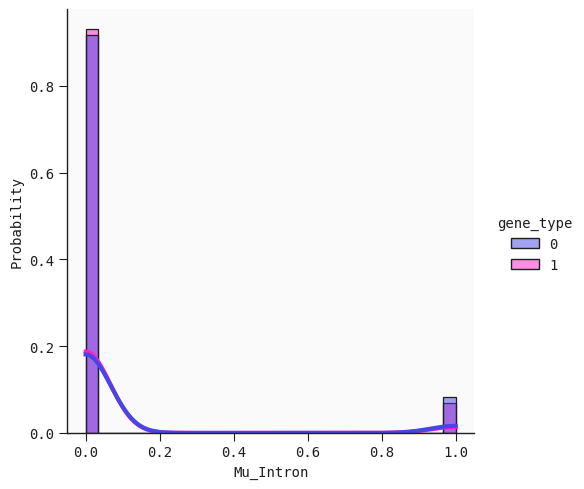

In [54]:
sns.displot(data[["Mu_Intron", "gene_type"]], x="Mu_Intron", hue="gene_type", kde=True, bins=30, stat="probability", common_norm=False)

### Mathematical expression

In [55]:
models[8].sympify(symbolic_lr = True)

1/(0.884485*exp(-1.50831*Cnmean + 0.350398*MuIntron + 0.487986*tanh(20.2535*MeIsland - 1.30381)) + 1)

In [56]:
models[0].sympify(symbolic_lr = True)

1/(0.902812*exp(-1.47839*Cnmean + 0.491404*tanh(19.9649*MeIsland - 1.26112)) + 1)

# Benchmark

### Random forest

In [25]:
# No feature selection
results_rf = random_forest_benchmark(data, target, n_jobs=100)
results_rf.mean()

0.6632727741795321

In [26]:
# Feature selection by mutual information (top 10)
results_rf_mi = random_forest_benchmark(data, target, feat_selection='mi', n_jobs=100)
results_rf_mi.mean()

0.6488094312303037

In [27]:
# Feature selection by mutual information (top 10)
results_rf_mi_top5 = random_forest_benchmark(data, target, feat_selection='mi', n_jobs=100)
results_rf_mi_top5.mean()

Traceback (most recent call last):
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/joblib/externals/loky/process_executor.py", line 391, in _process_worker
    call_item = call_queue.get(block=True, timeout=timeout)
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/multiprocessing/queues.py", line 99, in get
    if not self._rlock.acquire(block, timeout):
KeyboardInterrupt

Traceback (most recent call last):
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/joblib/externals/loky/process_executor.py", line 391, in _process_worker
    call_item = call_queue.get(block=True, timeout=timeout)
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/multiprocessing/queues.py", line 99, in get
    if not self._rlock.acquire(block, timeout):
KeyboardInterrupt

Traceback (mos

Process LokyProcess-17:
Traceback (most recent call last):
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/joblib/_parallel_backends.py", line 620, in __call__
    return self.func(*args, **kwargs)
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/joblib/parallel.py", line 289, in __call__
    for func, args, kwargs in self.items]
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/joblib/parallel.py", line 289, in <listcomp>
    for func, args, kwargs in self.items]
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/sklearn/utils/fixes.py", line 216, in __call__
    return self.function(*args, **kwargs)
  File "/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/QLattice_env/lib/python3.7/site-packages/sklearn/model_selec

KeyboardInterrupt: 